# 007 Liquidity Dynamics

Цель: понять, как изменения ликвидности (L1) связаны с движением цены на 200ms.

Фичи:
- delta_bid_l1 = bid_sz_01.diff()
- delta_ask_l1 = ask_sz_01.diff()
- liquidity_change = delta_bid_l1 - delta_ask_l1

Структура:
1. Load data
2. Compute feature
3. Build target (200ms)
4. Basic statistics
5. Distribution plots
6. Relationship to future price (binning)
7. Time series (downsampled)
8. Correlation analysis
9. Extreme events analysis


In [ ]:
# 1. Load data
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = None
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "pyproject.toml").exists() and (p / "research").is_dir():
        sys.path.insert(0, str(p))
        root = p
        break

root = root or Path.cwd()
data_dir = root / "data" / "reconstructed"

In [ ]:
parquet_path = data_dir / "BTC-USDT-SWAP" / "grid100ms" / "2026-03-04" / (
    "book_grid100ms_BTC-USDT-SWAP_2026-03-04_10-00-00__2026-03-04_11-00-00.parquet"
)
if not parquet_path.exists():
    found = sorted(data_dir.rglob("*.parquet"))
    parquet_path = found[0] if found else parquet_path
    if found:
        print("Default parquet not found, loading:", parquet_path)

df = pd.read_parquet(parquet_path)
df.head()

,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-04 10:00:00+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.9,0.02
1,2026-03-04 10:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.71,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.4,0.70
2,2026-03-04 10:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,333.47,71492.3,0.01,...,71494.9,0.73,71495.0,0.01,71495.3,0.70,71496.0,0.78,71496.2,0.70
3,2026-03-04 10:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,337.18,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71495.5,0.70,71496.0,0.08,71496.3,0.03
4,2026-03-04 10:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,353.48,71492.3,0.01,...,71495.0,0.01,71496.0,0.02,71496.9,0.02,71497.0,8.73,71497.3,0.30


In [ ]:
# 1 hour slice
_df = df.copy()
_df["ts_event"] = pd.to_datetime(_df["ts_event"], utc=True)
_df = _df.sort_values("ts_event").reset_index(drop=True)
start_ts = _df["ts_event"].min()
end_ts = start_ts + pd.Timedelta(hours=1)
_df = _df[_df["ts_event"].between(start_ts, end_ts)].reset_index(drop=True)
print("Rows:", len(_df))
print("Range:", _df["ts_event"].min(), "..", _df["ts_event"].max())

Rows: 36001
Range: 2026-03-04 10:00:00+00:00 .. 2026-03-04 11:00:00+00:00


In [ ]:
# 2. Compute feature
_df["mid_price"] = (_df["bid_px_01"] + _df["ask_px_01"]) / 2
_df["delta_bid_l1"] = _df["bid_sz_01"].diff().fillna(0)
_df["delta_ask_l1"] = _df["ask_sz_01"].diff().fillna(0)
_df["liquidity_change"] = _df["delta_bid_l1"] - _df["delta_ask_l1"]

_df[["ts_event", "delta_bid_l1", "delta_ask_l1", "liquidity_change"]].head()

,ts_event,delta_bid_l1,delta_ask_l1,liquidity_change
0,2026-03-04 10:00:00+00:00,0.00,0.00,0.00
1,2026-03-04 10:00:00.100000+00:00,0.00,0.00,0.00
2,2026-03-04 10:00:00.200000+00:00,-49.99,92.34,-142.33
3,2026-03-04 10:00:00.300000+00:00,3.71,-0.70,4.41
4,2026-03-04 10:00:00.400000+00:00,16.30,-207.51,223.81


In [ ]:
# 3. Target: 200ms future mid
_df["future_mid"] = _df["mid_price"].shift(-2)
_df["delta"] = _df["future_mid"] - _df["mid_price"]
_df["target"] = np.sign(_df["delta"]).astype("Int64")

_df2 = _df.dropna(subset=["future_mid"]).reset_index(drop=True)
print("Rows after shift:", len(_df2))

Rows after shift: 35999


liquidity_change
mean: -0.010777521597822096
std: 310.5640705281343
min: -2750.73 | max: 2689.87
% positive: 45.39848329120254
% negative: 50.62640628906359


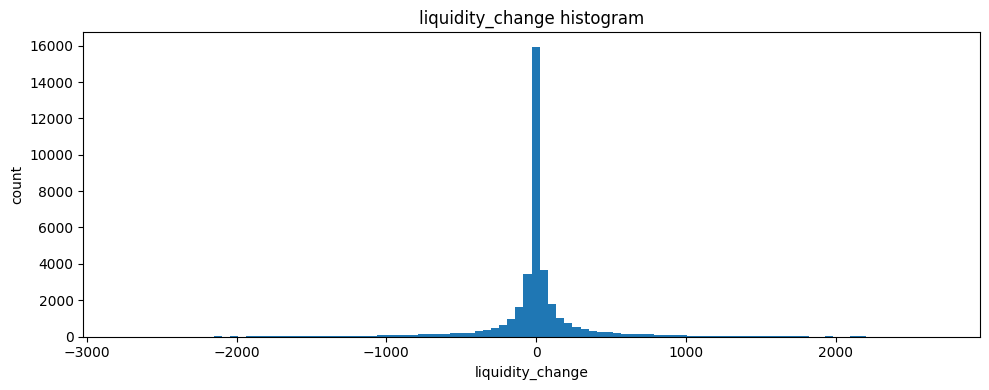

In [ ]:
# 4. Basic statistics
s = _df2["liquidity_change"].dropna()
print("liquidity_change")
print("mean:", s.mean())
print("std:", s.std())
print("min:", s.min(), "| max:", s.max())
print("% positive:", (s > 0).mean() * 100)
print("% negative:", (s < 0).mean() * 100)

# 5. Distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(s.values, bins=100)
ax.set_title("liquidity_change histogram")
ax.set_xlabel("liquidity_change")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

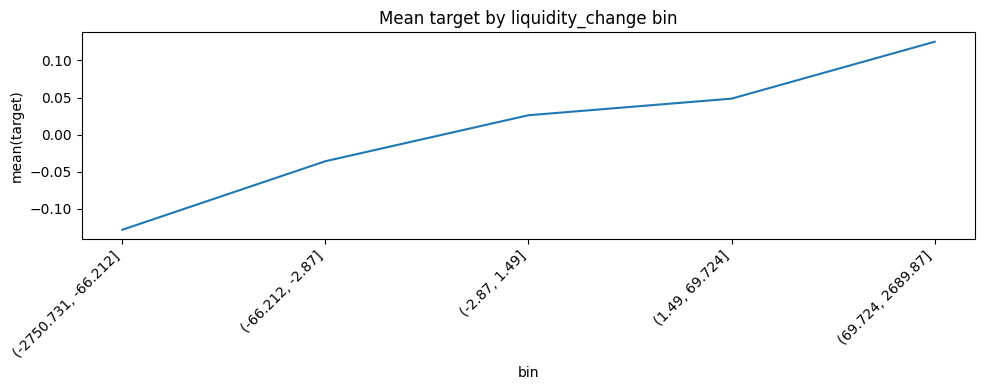

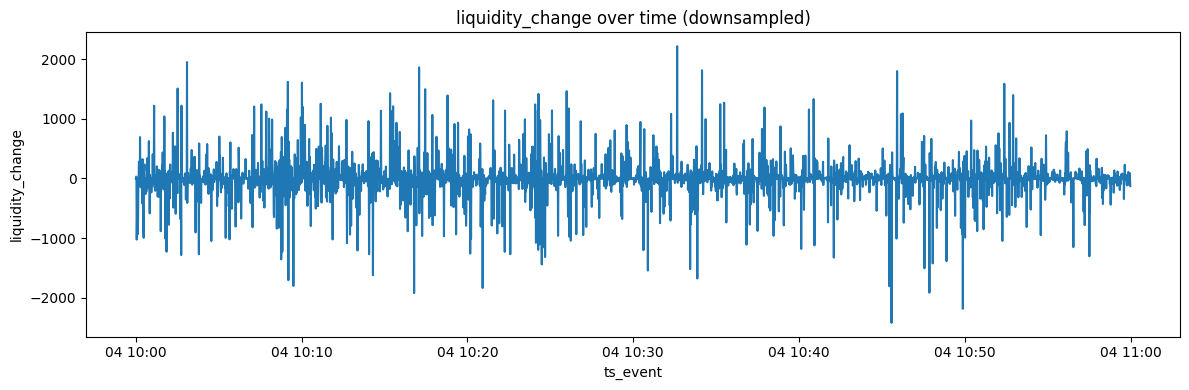

Correlation liquidity_change vs delta: 0.1559626630517646

Extreme events |liquidity_change| >= 99% quantile
threshold: 1357.0027999999977
count: 360
avg delta: -0.7945833333334626
mean target: -0.14444444444444443


In [ ]:
# 6. Relationship to future price (binning)
# Use quantile bins to avoid empty bins
_df2["bin"] = pd.qcut(_df2["liquidity_change"], q=5, duplicates="drop")
mean_target = _df2.groupby("bin", observed=True)["target"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(mean_target)), mean_target.values)
ax.set_title("Mean target by liquidity_change bin")
ax.set_xlabel("bin")
ax.set_ylabel("mean(target)")
ax.set_xticks(range(len(mean_target)))
ax.set_xticklabels([str(x) for x in mean_target.index], rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7. Time series (downsample)
down = _df2.iloc[::10].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(down["ts_event"], down["liquidity_change"].values)
ax.set_title("liquidity_change over time (downsampled)")
ax.set_xlabel("ts_event")
ax.set_ylabel("liquidity_change")
plt.tight_layout()
plt.show()

# 8. Correlation analysis
print("Correlation liquidity_change vs delta:", _df2["liquidity_change"].corr(_df2["delta"]))

# 9. Extreme events analysis (liquidity removal)
thr = _df2["liquidity_change"].abs().quantile(0.99)
ext = _df2[_df2["liquidity_change"].abs() >= thr]
print("\nExtreme events |liquidity_change| >= 99% quantile")
print("threshold:", thr)
print("count:", len(ext))
print("avg delta:", ext["delta"].mean())
print("mean target:", ext["target"].mean())